<a href="https://colab.research.google.com/github/rasyadtanzilur/pengolahancitra/blob/main/minggu1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

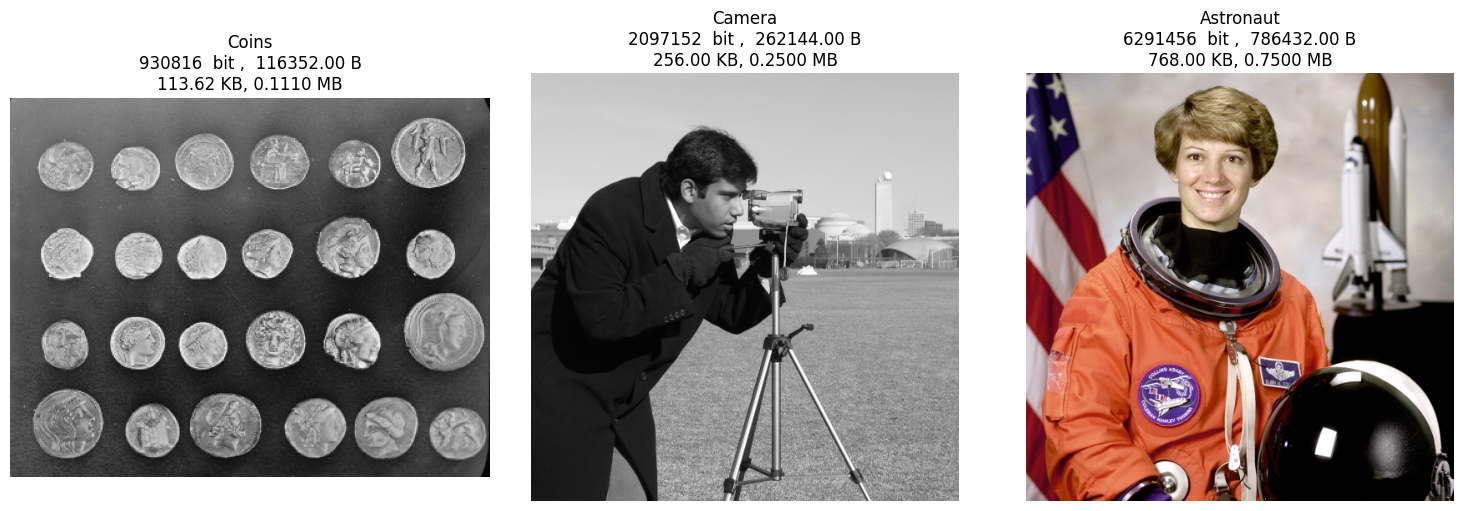

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

# contoh gambar dari scikit-image
gambar_coins = data.coins()
gambar_camera = data.camera()
gambar_astronaut = data.astronaut()

# Fungsi untuk menghitung ukuran gambar dalam bit, byte, KB, MB
def hitung_ukuran(image):
    bit_per_pixel = 8 if len(image.shape) == 2 else 24  # Grayscale = 8, RGB 24 bit
    total_pixels = image.shape[0] * image.shape[1]
    total_bits = total_pixels * bit_per_pixel
    total_bytes = total_bits / 8
    total_kb = total_bytes / 1024
    total_mb = total_kb / 1024
    return total_bits, total_bytes, total_kb, total_mb

# Menyusun gambar dan ukurannya dalam satu baris
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Daftar gambar dan nama
gambar_list = [gambar_coins, gambar_camera, gambar_astronaut]
nama_list = ["Coins", "Camera", "Astronaut"]

for ax, img, nama in zip(axes, gambar_list, nama_list):
    bits, bytes_, kb, mb = hitung_ukuran(img)
    ax.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    ax.set_title(f"{nama}\n{bits}  bit ,  {bytes_:.2f} B\n{kb:.2f} KB, {mb:.4f} MB")
    ax.axis('off')  # This line was incorrectly indented

plt.tight_layout()
plt.show()

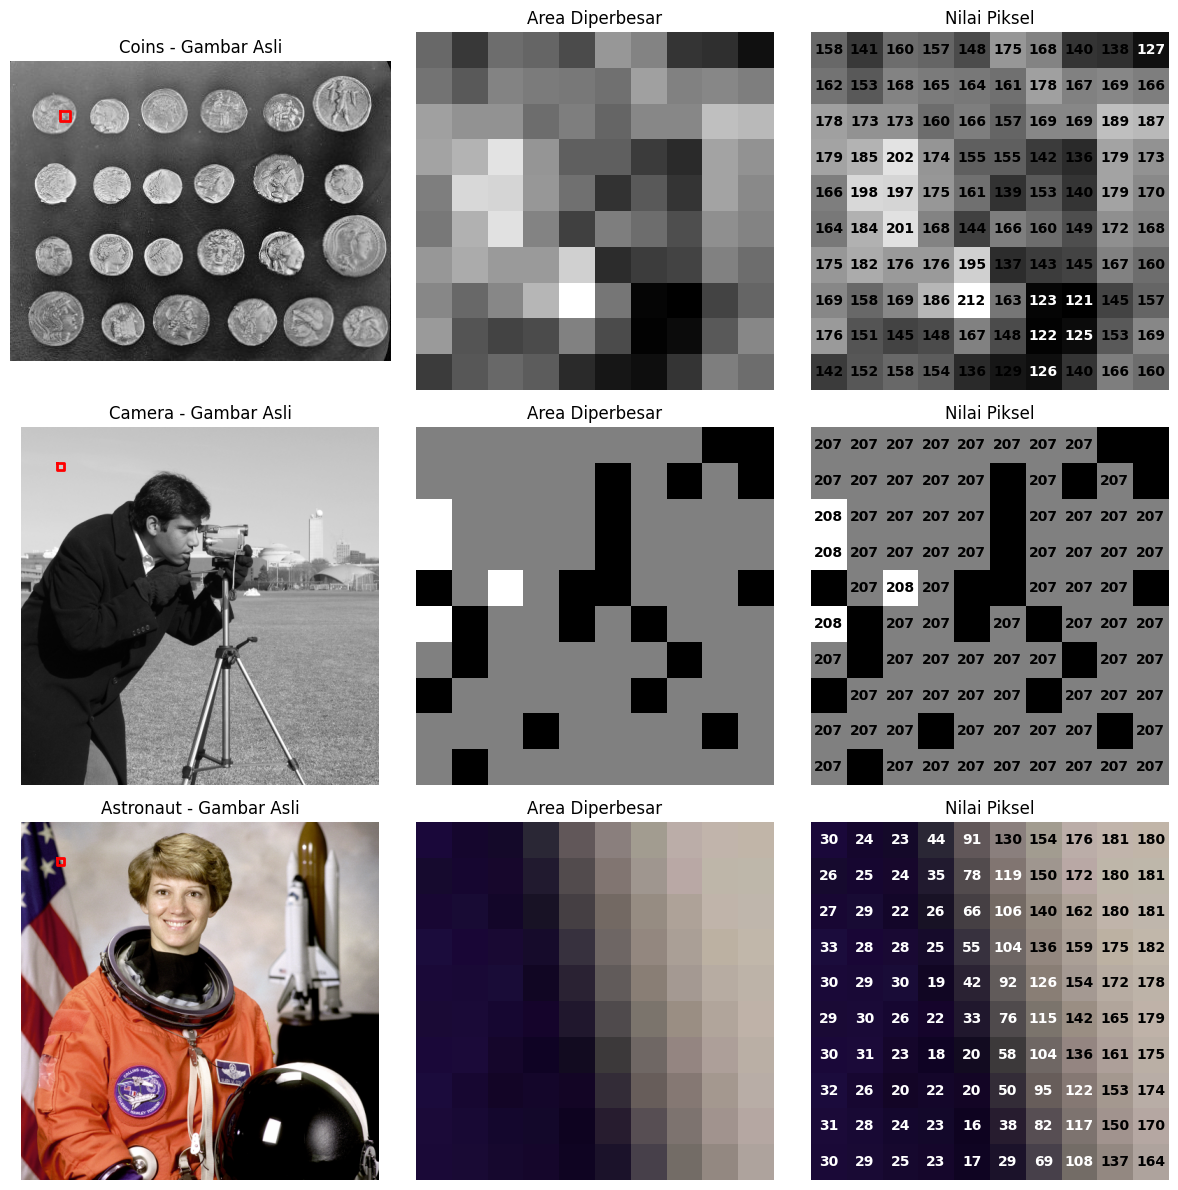

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

# Ambil gambar dari skimage.data
gambar_coins = data.coins()
gambar_camera = data.camera()
gambar_astronaut = data.astronaut()

# Buat figure dengan 3 baris dan 3 kolom
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

# Daftar gambar dan nama
gambar_list = [gambar_coins, gambar_camera, gambar_astronaut]
nama_list = ["Coins", "Camera", "Astronaut"]

# Koordinat area fokus (zoom)
x_start, x_end = 50, 60
y_start, y_end = 50, 60

for i, (img, nama) in enumerate(zip(gambar_list, nama_list)):
    # --- 1. Gambar Asli ---
    axes[i, 0].imshow(img, cmap='gray' if img.ndim == 2 else None)
    axes[i, 0].set_title(f"{nama} - Gambar Asli")
    axes[i, 0].axis('off')

    # Tambahkan kotak merah sebagai penanda area fokus
    rect_x = [x_start, x_end, x_end, x_start, x_start]
    rect_y = [y_start, y_start, y_end, y_end, y_start]
    axes[i, 0].plot(rect_x, rect_y, color="red", linewidth=2)

    # --- 2. Gambar Fokus Area ---
    zoomed_img = img[y_start:y_end, x_start:x_end]
    axes[i, 1].imshow(zoomed_img, cmap='gray' if img.ndim == 2 else None, interpolation='nearest')
    axes[i, 1].set_title("Area Diperbesar")
    axes[i, 1].axis('off')

    # --- 3. Nilai Piksel ---
    axes[i, 2].imshow(zoomed_img, cmap='gray' if img.ndim == 2 else None, interpolation='nearest')
    for y in range(zoomed_img.shape[0]):
        for x in range(zoomed_img.shape[1]):
            if img.ndim == 3:  # Gambar RGB
                pixel_value = int(np.mean(zoomed_img[y, x]))
            else:  # Grayscale
                pixel_value = zoomed_img[y, x]

            # Tentukan warna teks agar kontras
            text_color = "white" if pixel_value < 128 else "black"
            axes[i, 2].text(x, y, str(pixel_value), color=text_color,
                            ha='center', va='center', fontsize=10, fontweight='bold')

    axes[i, 2].set_title("Nilai Piksel")
    axes[i, 2].axis('off')

# Tata letak rapi
plt.tight_layout()
plt.show()


JOB MINGGU 01: DASAR BERKAS GAMBAR (CITRA)